<a href="https://colab.research.google.com/github/Nmg1994/CTGAN_Synthetic_Data_Creation/blob/main/CTGAN_SyntheticDatasetCreation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing necessary packages

In [ ]:
pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.0 MB/s eta 0:00:00


# Importing necessary libraries/modules

In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN

# Mounting Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# CTGAN developement

In [ ]:
PUMFs_df = pd.read_csv("/content/drive/My Drive/SyntheticDataset/data_donnees_2021_ind_v2.csv", low_memory=False)

In [ ]:
Columns = ['AGEGRP', 'Gender', 'CitOth', 'IMMSTAT', 'HDGREE', 'COW', 'HHSIZE', 'PR'] # Age group, gender, Citizenship, Immigrant status, Highest degree, Labour: Class of worker, Household size, Province
PUMFs_df_selected = PUMFs_df[Columns]
PUMFs_df_selected.to_csv("/content/drive/My Drive/SyntheticDataset/PUMFs_df_selected.csv", index=False)

In [ ]:
PUMFs_df_selected = pd.read_csv("/content/drive/My Drive/SyntheticDataset/PUMFs_df_selected.csv")
PUMFs_df_selected.dropna(inplace=True)
PUMFs_df_selected_cleaned = PUMFs_df_selected[~PUMFs_df_selected.isin([88, 99]).any(axis=1)].reset_index(drop=True) # Removing not available (i.e., 88) and not applicable (i.e., 99) rows/records
# One-hot encode all categorical columns
categorical_cols = ['AGEGRP', 'Gender', 'CitOth', 'IMMSTAT', 'HDGREE', 'COW', 'HHSIZE', 'PR']

In [ ]:
# Train CTGAN
ctgan = CTGAN(epochs=100, batch_size=500, generator_dim=(128,128), discriminator_dim=(128,128), verbose=True)
ctgan.fit(PUMFs_df_selected_cleaned, discrete_columns=categorical_cols)

Gen. (-0.24) | Discrim. (-0.08): 100%|██████████| 100/100 [4:23:02<00:00, 157.83s/it]


In [ ]:
synthetic_df = ctgan.sample(len(PUMFs_df_selected_cleaned))   # the same size of the real dataset
synthetic_df.to_csv("/content/drive/My Drive/SyntheticDataset/synthetic_census_data.csv", index=False)

# Performance evaluation

In [ ]:
synthetic_df = pd.read_csv("/content/drive/My Drive/SyntheticDataset/synthetic_census_data.csv")
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1))

def cramers_v_matrix(df, cols):
    size = len(cols)
    m = pd.DataFrame(np.zeros((size, size)), index=cols, columns=cols)

    for i in range(size):
        for j in range(size):
            m.iloc[i, j] = cramers_v(df[cols[i]], df[cols[j]])

    return m


In [ ]:
categorical_cols = ['AGEGRP','Gender','CitOth','IMMSTAT',
                    'HDGREE','COW','HHSIZE','PR']

real_corr = cramers_v_matrix(PUMFs_df_selected_cleaned, categorical_cols)
synthetic_corr = cramers_v_matrix(synthetic_df, categorical_cols)

difference_corr = real_corr - synthetic_corr


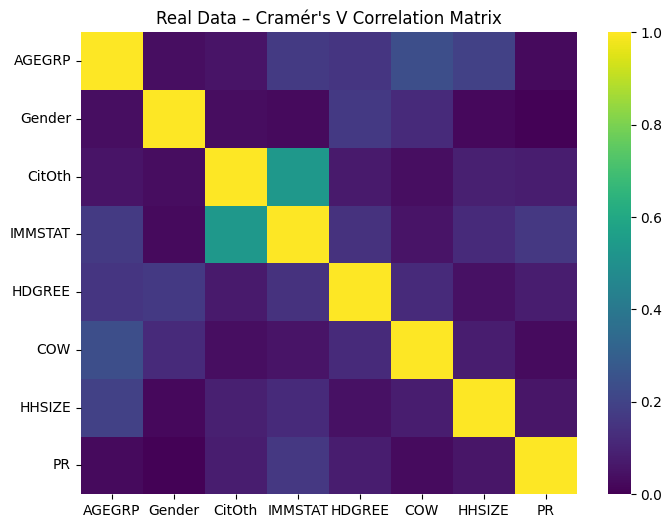

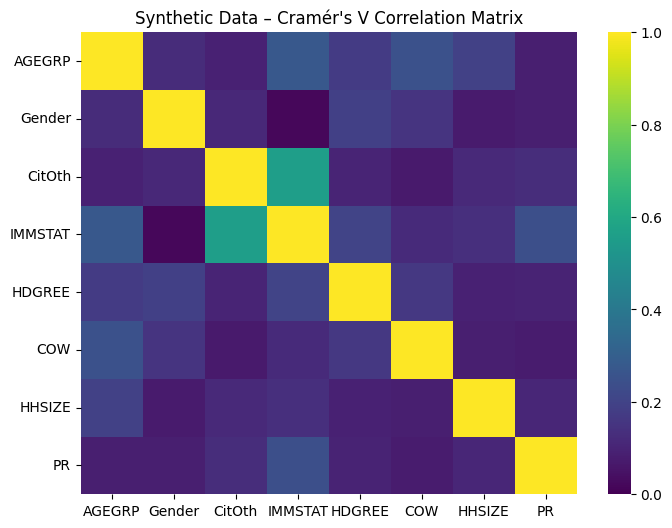

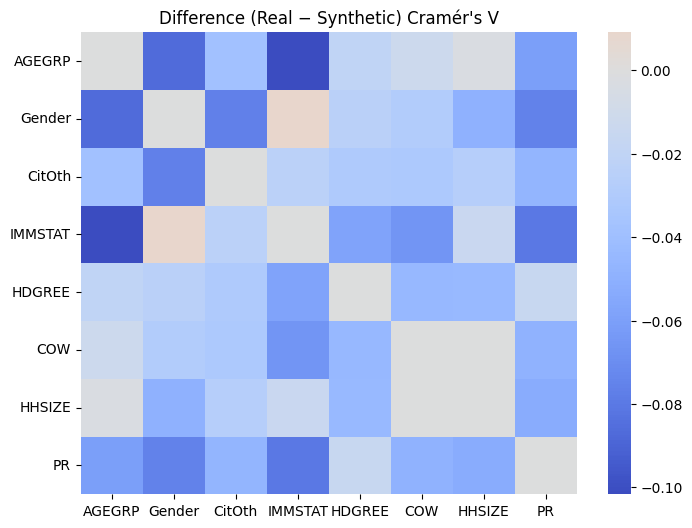

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(real_corr, cmap="viridis", vmin=0, vmax=1)
plt.title("Real Data – Cramér's V Correlation Matrix")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(synthetic_corr, cmap="viridis", vmin=0, vmax=1)
plt.title("Synthetic Data – Cramér's V Correlation Matrix")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(difference_corr, cmap="coolwarm", center=0)
plt.title("Difference (Real − Synthetic) Cramér's V")
plt.show()


In [ ]:
def total_variation_distance(real_df, synth_df, categorical_cols):
    for col in categorical_cols:
        real_p = real_df[col].value_counts(normalize=True)
        synth_p = synth_df[col].value_counts(normalize=True)

        idx = real_p.index.union(synth_p.index)

        real_p = real_p.reindex(idx, fill_value=0)
        synth_p = synth_p.reindex(idx, fill_value=0)

        tvd = 0.5 * (real_p - synth_p).abs().sum()

        print(f"{col}: TVD = {tvd:.4f}")

total_variation_distance(PUMFs_df_selected_cleaned,
                         synthetic_df,
                         categorical_cols)




AGEGRP: TVD = 0.0749
Gender: TVD = 0.0259
CitOth: TVD = 0.1277
IMMSTAT: TVD = 0.1382
HDGREE: TVD = 0.0733
COW: TVD = 0.0682
HHSIZE: TVD = 0.0776
PR: TVD = 0.0642


In [ ]:
from scipy.spatial.distance import jensenshannon

def jsd_test(real_df, synth_df, categorical_cols):
    for col in categorical_cols:
        real_p = real_df[col].value_counts(normalize=True)
        synth_p = synth_df[col].value_counts(normalize=True)

        idx = real_p.index.union(synth_p.index)
        real_p = real_p.reindex(idx, fill_value=0)
        synth_p = synth_p.reindex(idx, fill_value=0)

        jsd = jensenshannon(real_p, synth_p)
        print(f"{col}: JSD = {jsd:.4f}")

jsd_test(PUMFs_df_selected_cleaned,
                         synthetic_df,
                         categorical_cols)

AGEGRP: JSD = 0.0669
Gender: JSD = 0.0183
CitOth: JSD = 0.1174
IMMSTAT: JSD = 0.1097
HDGREE: JSD = 0.0707
COW: JSD = 0.0954
HHSIZE: JSD = 0.0753
PR: JSD = 0.0752


In [ ]:
import matplotlib.pyplot as plt

def plot_categorical_distributions(real_df, synth_df, categorical_cols):
    for col in categorical_cols:
        plt.figure(figsize=(6, 4))

        real_counts = real_df[col].value_counts(normalize=True)
        synth_counts = synth_df[col].value_counts(normalize=True)

        combined_index = real_counts.index.union(synth_counts.index)

        real_aligned = real_counts.reindex(combined_index, fill_value=0)
        synth_aligned = synth_counts.reindex(combined_index, fill_value=0)

        x = range(len(combined_index))

        plt.bar(x, real_aligned, width=0.4, label='Real', align='center')
        plt.bar([i + 0.4 for i in x], synth_aligned, width=0.4, label='Synthetic')

        plt.title(f"Distribution Comparison for {col}")
        plt.xticks([i + 0.2 for i in x], combined_index, rotation=45)
        plt.ylabel("Proportion")
        plt.legend()
        plt.tight_layout()
        plt.show()



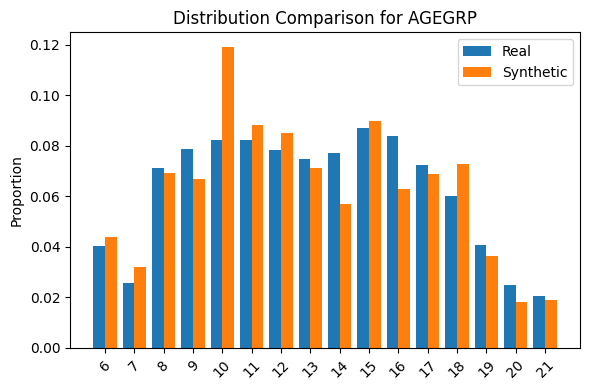

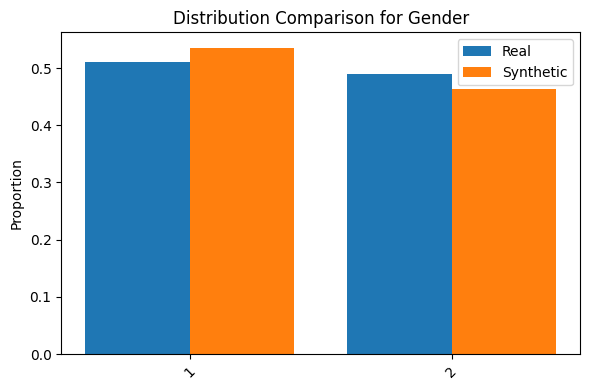

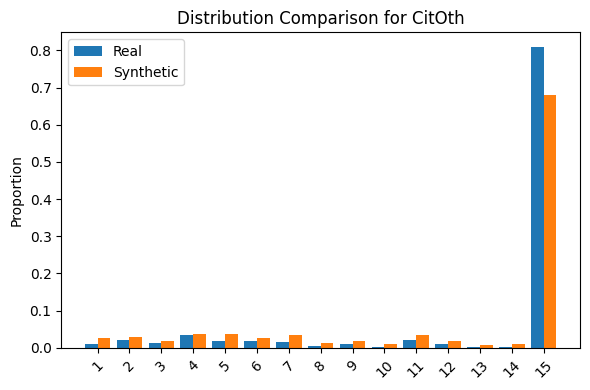

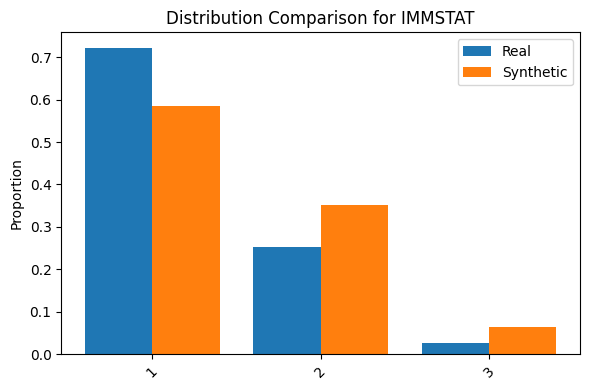

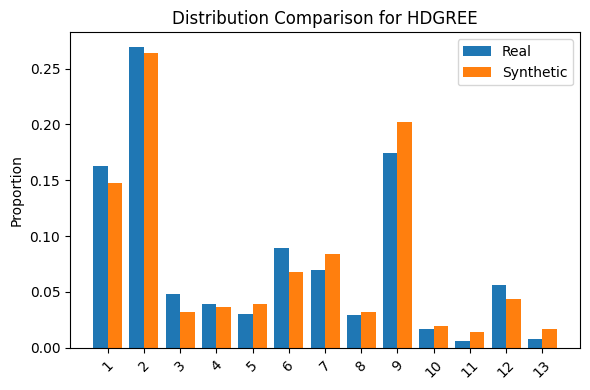

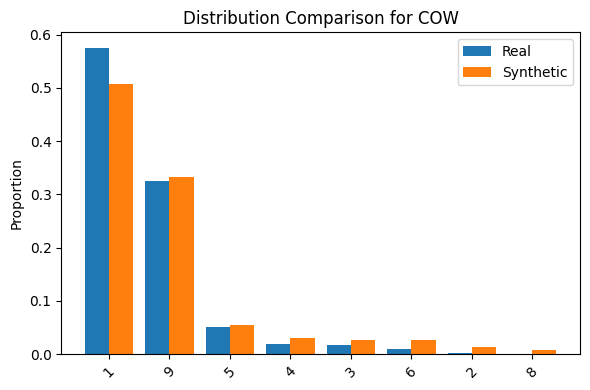

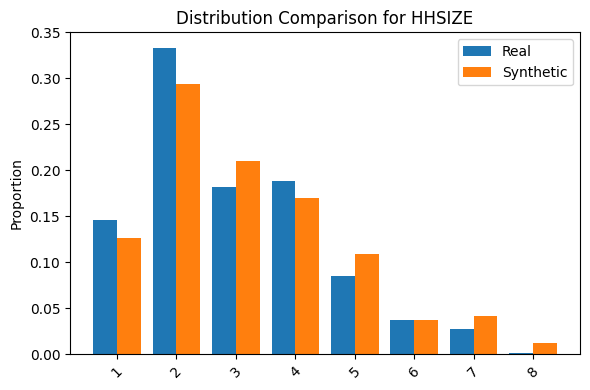

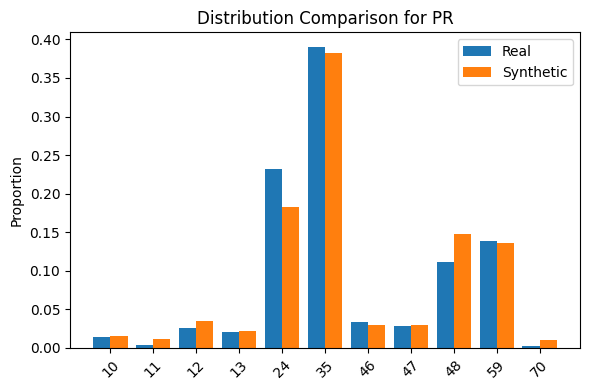

In [ ]:
plot_categorical_distributions(PUMFs_df_selected_cleaned,
                               synthetic_df,
                               categorical_cols)

